# Image Retrieval on Texture Dataset

Given a **query image** and **K**, returns the **K most similar images** from the Texture database with their class labels.

**Pipeline:**
1. Load a pre-trained ViT/Swin/GCViT model
2. Extract the feature vector of the query image
3. Compute cosine similarity against the entire database
4. Return the K images with the highest similarity scores

## 1. Imports & Configuration

In [2]:
import os
import numpy as np
import pandas as pd
import torch
import timm
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from PIL import Image
from torch.nn import CosineSimilarity

# ── Configuration ─────────────────────────────────────────────────────────────

# Model name: vit_s16 | swin_s | gcvit_s
MODEL_NAME = "vit_s16"

TIMM_MODELS = {
    "vit_s16": "vit_small_patch16_224.augreg_in1k",
    "swin_s":  "swin_small_patch4_window7_224.ms_in1k",
    "gcvit_s": "gcvit_small.in1k",
}
MODEL_TIMM = TIMM_MODELS[MODEL_NAME]

# Path to pre-extracted database features (pickle file from extract_features.py)
DB_FEATURES_PATH = f"./texture_features/{MODEL_NAME}_texture.pkl"

# Root directory of the Texture dataset images
DATASET_DIR = "./dataset"

# Must match the weights used when running extract_features.py.
# None → ImageNet pretrained; Path → fine-tuned checkpoint
WEIGHTS = "./model_save/vit_s16_texture.pth"

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")
print(f"Model:  {MODEL_NAME} ({MODEL_TIMM})")
print(f"DB features path: {DB_FEATURES_PATH}")
print(f"Weights: {WEIGHTS if WEIGHTS else 'ImageNet pretrained (None)'}")

Device: cuda
Model:  vit_s16 (vit_small_patch16_224.augreg_in1k)
DB features path: ./texture_features/vit_s16_texture.pkl
Weights: ./model_save/vit_s16_texture.pth


## 2. Load Model & Database Features

In [3]:
if WEIGHTS and not os.path.exists(WEIGHTS):
    raise FileNotFoundError(
        f"Weights file not found: {WEIGHTS}\n"
        "Check the path or set WEIGHTS = None to use ImageNet pretrained weights."
    )

if torch.cuda.is_available():
    torch.cuda.empty_cache()
    free_mem, total_mem = torch.cuda.mem_get_info()
    print(f"GPU VRAM: {free_mem/1024**3:.1f} GB free / {total_mem/1024**3:.1f} GB total")

print(f"Loading model with weights: {WEIGHTS if WEIGHTS else 'ImageNet pretrained'}")
if WEIGHTS:
    model = timm.create_model(MODEL_TIMM, num_classes=0, checkpoint_path=WEIGHTS)
else:
    model = timm.create_model(MODEL_TIMM, pretrained=True, num_classes=0)
model.eval()

# Fall back to CPU if GPU is out of memory
try:
    model.to(device)
    compute_device = device
    print(f"Model loaded on: {compute_device}")
except RuntimeError as e:
    if "out of memory" in str(e).lower() or "AcceleratorError" in str(type(e).__name__):
        torch.cuda.empty_cache()
        compute_device = torch.device("cpu")
        model.to(compute_device)
        print(f"CUDA OOM — falling back to CPU. Model loaded on: {compute_device}")
    else:
        raise

transform = timm.data.create_transform(
    **timm.data.resolve_data_config(model.pretrained_cfg)
)
print(f"Transform: {transform.transforms[0]}, {transform.transforms[1]}, ...")

print("\nLoading database features...")
if not os.path.exists(DB_FEATURES_PATH):
    raise FileNotFoundError(
        f"Features file not found: {DB_FEATURES_PATH}\n"
        f"Run extract_features.py first:  python extract_features.py --model {MODEL_NAME}"
    )

db_df       = pd.read_pickle(DB_FEATURES_PATH)
db_matrix   = torch.tensor(
    np.array(db_df[MODEL_NAME].tolist()), dtype=torch.float32
).to(compute_device)                             # [N, D]
db_labels   = db_df["labels"].values.astype(int) # [N]
db_filepaths = db_df["filepath"].tolist()         # [N] relative paths: train/<class>/<N>.jpg

# Build class name list from folder names (sorted to match ImageFolder label order)
CLASSES = sorted([
    d for d in os.listdir(os.path.join(DATASET_DIR, "train"))
    if os.path.isdir(os.path.join(DATASET_DIR, "train", d))
])

print(f"Database: {len(db_df):,} images | feature dim: {db_matrix.shape[1]}")
print(f"Classes ({len(CLASSES)}): {CLASSES[:5]} ...")
print("\nReady!")

GPU VRAM: 2.8 GB free / 23.5 GB total
Loading model with weights: ./model_save/vit_s16_texture.pth
Model loaded on: cuda
Transform: Resize(size=248, interpolation=bicubic, max_size=None, antialias=True), CenterCrop(size=(224, 224)), ...

Loading database features...
Database: 4,335 images | feature dim: 384
Classes (64): ['KTH_aluminium_foil', 'KTH_brown_bread', 'KTH_corduroy', 'KTH_cork', 'KTH_cotton'] ...

Ready!


## 3. Feature Extraction & Retrieval Functions

In [4]:
def encode_image(pil_image: Image.Image) -> torch.Tensor:
    """Extract a feature vector from a PIL image."""
    img_tensor = transform(pil_image).unsqueeze(0).to(compute_device)  # [1, C, H, W]
    with torch.no_grad():
        feat = model(img_tensor)  # [1, D]
    return feat.squeeze(0)  # [D]


def retrieve_top_k(
    query_image: Image.Image,
    k: int,
    db_matrix: torch.Tensor,
    db_labels: np.ndarray,
    db_filepaths: list,
    exclude_path: str = None,
) -> dict:
    """
    Find the K most similar images to query_image in the Texture database.

    Args:
        query_image  : query image (PIL.Image)
        k            : number of results to return
        db_matrix    : database feature matrix [N, D]
        db_labels    : corresponding integer labels [N]
        db_filepaths : list of relative file paths [N]
        exclude_path : relative filepath to exclude from results (when query is in the DB)

    Returns:
        dict with keys: scores, indices, labels, class_names, images
    """
    query_feat = encode_image(query_image)  # [D]

    cos_sim = CosineSimilarity(dim=1)
    scores  = cos_sim(db_matrix, query_feat.unsqueeze(0))  # [N]

    # Exclude query from its own results if it exists in the database
    if exclude_path is not None and exclude_path in db_filepaths:
        scores[db_filepaths.index(exclude_path)] = -2.0

    topk_scores, topk_indices = torch.topk(scores, k=k)
    topk_indices = topk_indices.cpu().numpy()
    topk_scores  = topk_scores.cpu().numpy()

    topk_labels     = db_labels[topk_indices]
    topk_classnames = [CLASSES[lbl] for lbl in topk_labels]
    topk_images     = [
        Image.open(os.path.join(DATASET_DIR, fp)).convert("RGB")
        for fp in [db_filepaths[i] for i in topk_indices]
    ]

    return {
        "scores"     : topk_scores,
        "indices"    : topk_indices,
        "labels"     : topk_labels,
        "class_names": topk_classnames,
        "images"     : topk_images,
    }


def display_results(
    query_image: Image.Image,
    results: dict,
    query_label: int = None,
    figsize_per_img: float = 2.0,
):
    """
    Display the query image alongside the K retrieved results.
    Green border = correct label, red border = wrong label (only when query_label is known).
    """
    k     = len(results["images"])
    ncols = k + 1
    fig, axes = plt.subplots(1, ncols, figsize=(ncols * figsize_per_img, figsize_per_img * 1.6))

    ax = axes[0]
    ax.imshow(query_image)
    title = "QUERY"
    if query_label is not None:
        title += f"\n({CLASSES[query_label]})"
    ax.set_title(title, fontsize=8, fontweight="bold")
    ax.axis("off")
    for spine in ax.spines.values():
        spine.set_edgecolor("blue")
        spine.set_linewidth(3)
        spine.set_visible(True)

    for i, (img, lbl, cls, score) in enumerate(
        zip(results["images"], results["labels"], results["class_names"], results["scores"])
    ):
        ax = axes[i + 1]
        ax.imshow(img)
        ax.set_title(f"#{i+1} {cls}\n{score:.3f}", fontsize=7)
        ax.axis("off")
        if query_label is not None:
            color = "green" if lbl == query_label else "red"
            for spine in ax.spines.values():
                spine.set_edgecolor(color)
                spine.set_linewidth(2.5)
                spine.set_visible(True)

    if query_label is not None:
        patches = [
            mpatches.Patch(color="green", label="Correct label"),
            mpatches.Patch(color="red",   label="Wrong label"),
        ]
        fig.legend(handles=patches, loc="lower center", ncol=2, fontsize=8,
                   bbox_to_anchor=(0.5, -0.05))

    plt.suptitle(f"Top-{k} retrieval  |  model: {MODEL_NAME}", fontsize=9, y=1.02)
    plt.tight_layout()
    plt.show()

print("Retrieval functions ready.")

Retrieval functions ready.


## 4. Query Image & K Selection

Query image: /home/sotatek/Documents/Image_Retrieval/image-retrieval-using-transformers/Texture/2.jpg


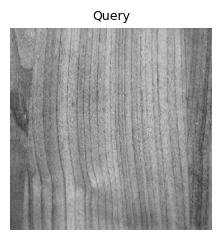

K = 10


In [5]:
# ── Input Parameters ──────────────────────────────────────────────────────────

K = 10  # Number of retrieved images

# Path to a custom query image (PNG/JPG/...)
CUSTOM_IMAGE_PATH = "/home/sotatek/Documents/Image_Retrieval/image-retrieval-using-transformers/Texture/2.jpg"

# ──────────────────────────────────────────────────────────────────────────────

query_pil       = Image.open(CUSTOM_IMAGE_PATH).convert("RGB")
query_label_int = None
query_filepath  = None
print(f"Query image: {CUSTOM_IMAGE_PATH}")

plt.figure(figsize=(2.5, 2.5))
plt.imshow(query_pil)
plt.title("Query", fontsize=9)
plt.axis("off")
plt.tight_layout()
plt.show()

print(f"K = {K}")

## 5. Retrieval & Results

In [6]:
import time

t0 = time.time()
results = retrieve_top_k(
    query_image  = query_pil,
    k            = K,
    db_matrix    = db_matrix,
    db_labels    = db_labels,
    db_filepaths = db_filepaths,
    exclude_path = query_filepath,
)
elapsed = time.time() - t0
print(f"Retrieval completed in {elapsed*1000:.1f} ms\n")

print(f"{'Rank':<6} {'Index':<8} {'Label':<6} {'Class':<30} {'Cosine Sim':<12}")
print("-" * 65)
for rank, (idx, lbl, cls, score) in enumerate(
    zip(results["indices"], results["labels"], results["class_names"], results["scores"]), 1
):
    marker = "✓" if (query_label_int is not None and lbl == query_label_int) else " "
    print(f"{rank:<6} {idx:<8} {lbl:<6} {cls:<30} {score:.4f}  {marker}")

if query_label_int is not None:
    n_correct = sum(lbl == query_label_int for lbl in results["labels"])
    print(f"\nCorrect labels: {n_correct}/{K}  ({n_correct/K*100:.0f}%)")

Retrieval completed in 248.0 ms

Rank   Index    Label  Class                          Cosine Sim  
-----------------------------------------------------------------
1      3908     42     UIUC04_wood1                   0.9080   
2      3904     42     UIUC04_wood1                   0.8639   
3      3914     42     UIUC04_wood1                   0.8624   
4      3912     42     UIUC04_wood1                   0.8465   
5      3903     42     UIUC04_wood1                   0.8280   
6      3907     42     UIUC04_wood1                   0.8226   
7      3911     42     UIUC04_wood1                   0.8166   
8      3906     42     UIUC04_wood1                   0.8145   
9      3895     42     UIUC04_wood1                   0.8105   
10     3913     42     UIUC04_wood1                   0.8042   


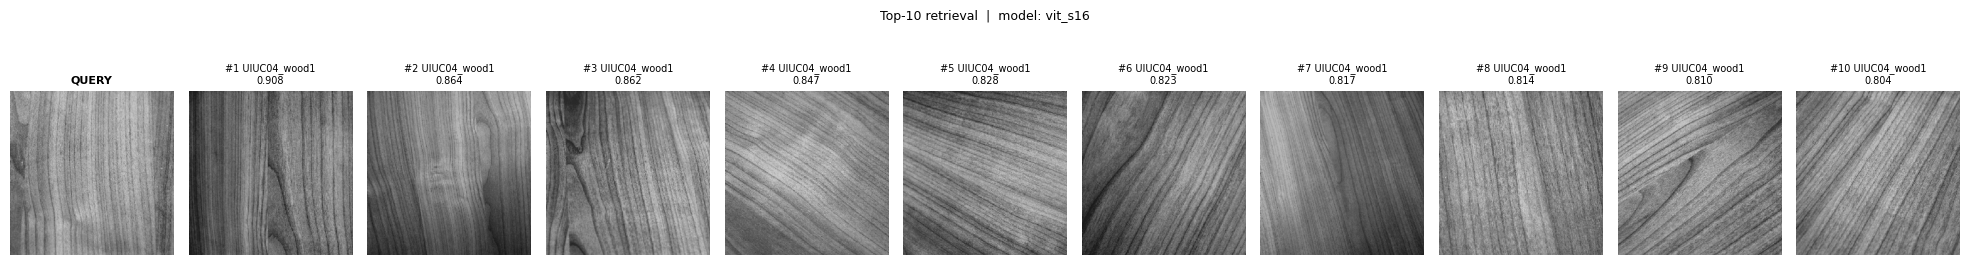

In [7]:
display_results(
    query_image     = query_pil,
    results         = results,
    query_label     = query_label_int,
    figsize_per_img = 1.8,
)